<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/6_1_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 6 – Relationships Between Variables 1

In this notebook, we will learn how to quickly explore and interpret the **relationship between two (or more) variables**.

The goal is not simply to “get a number,” but to be able to answer:

- Is there a relationship between two variables?
- What is its direction (positive / negative), and how strong is it?
- Is the calculated correlation also reflected in the raw data?

To do this, we always use two things together:

1. **Correlation matrix / heatmap** → a quick overview of many variables
2. **Scatter plot** → visual verification: does the relationship really look the way the number suggests?

Important note:
- Correlation does **not** mean causation; it only indicates association.
- Correlation can be sensitive to outliers and to the distribution of the variables.

## Wine dataset

The Wine dataset is a classic and frequently used dataset
that describes wines based on different chemical measurements.
Each row represents one wine, and the columns contain
numerical features derived from laboratory measurements.

The data belongs to three different wine classes,
so it is well suited for examining distributions,
relationships between variables,
as well as correlations.

In [ ]:
# Loading the WINE dataset
# The Wine dataset is a classic, fully numerical dataset
# that is often used for teaching statistical analysis and machine learning.

from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

# Loading the data
wine = load_wine(as_frame=True)
df = wine.frame.copy()
display(df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


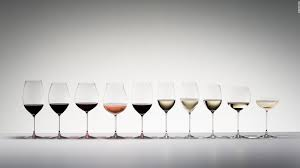

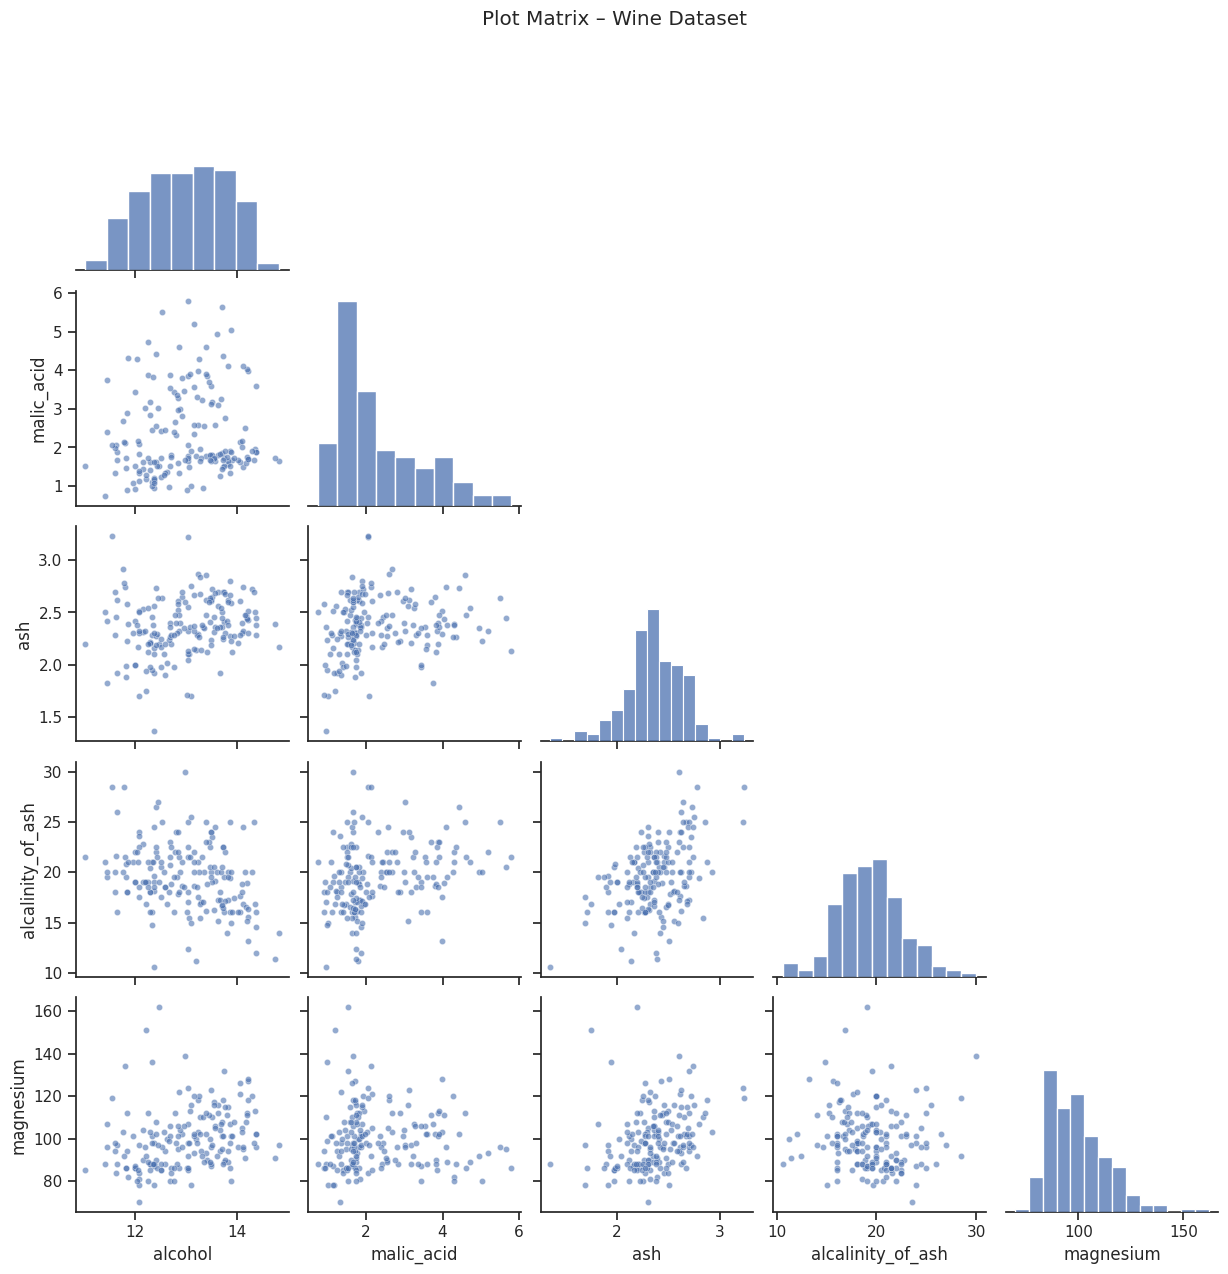

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Setting the default Seaborn style
# The "ticks" style provides clean axes and readable markings
sns.set(style="ticks")

# Creating a plot matrix (pairplot)
# This figure plots every numerical column against every other one
sns.pairplot(
    df.iloc[:,:5],                  # DataFrame containing only the numerical columns
    diag_kind="hist",     # On the main diagonal, it shows the univariate distribution with a histogram
    corner=True,         # Draws only the lower triangle (clearer layout)
    plot_kws={
        "alpha": 0.6,    # Transparency of the points (helps handle overlaps)
        "s": 20          # Size of the points
    }
)

# Title of the figure
plt.suptitle(
    "Plot Matrix – Wine Dataset",
    y=1.02              # Vertical offset of the title so it does not overlap the figure
)

# Displaying the figure
plt.show()


## Correlation and Covariance

In the previous steps, we examined the distribution of individual variables.
Now we will look at **how the variables relate to each other**.

Correlation and covariance describe whether two variables
change together, and if so, in what direction and to what extent.

It is important to understand that these values are **sensitive to the distribution,
to outliers, and to the handling of missing data**.


### Covariance

Covariance shows whether two variables
increase or decrease together.

- positive covariance: they increase together
- negative covariance: one increases while the other decreases
- value around 0: no linear relationship

However, the magnitude of covariance **depends on the unit of measurement**,
so on its own it is difficult to interpret.


In [ ]:
# Calculating covariance for a few variables
cols = ["alcohol", "malic_acid", "ash", "magnesium", "flavanoids", "total_phenols"]
df[cols].cov()

,alcohol,malic_acid,ash,magnesium,flavanoids,total_phenols
alcohol,0.659062,0.085611,0.047115,3.139878,0.192033,0.146887
malic_acid,0.085611,1.248015,0.050277,-0.870780,-0.458630,-0.234338
ash,0.047115,0.050277,0.075265,1.122937,0.031535,0.022146
magnesium,3.139878,-0.870780,1.122937,203.989335,2.793087,1.916470
flavanoids,0.192033,-0.458630,0.031535,2.793087,0.997719,0.540470
total_phenols,0.146887,-0.234338,0.022146,1.916470,0.540470,0.391690


**What do we see in the covariance matrix?**

On the diagonal we see the covariance of each variable with itself (its variance),
which is why these values are larger and may differ in magnitude.
The off-diagonal elements show how two different variables
change together and in which direction.

For example, the negative covariance between `malic_acid` and `magnesium`
suggests that when one increases, the other tends to decrease.
However, it is important to note that the magnitude of covariance depends on the units of measurement,
so primarily the **sign** is interpretable.

“How can we interpret this independently of the measurement units?” → correlation.

### Correlation

Correlation is the normalized version of covariance, and its value always lies between -1 and 1.

+1: perfect positive linear relationship  
-1: perfect negative linear relationship  
0: no linear relationship


In [ ]:
# Pearson correlation
df[cols].corr()  # by default, it calculates PEARSON correlation


,alcohol,malic_acid,ash,magnesium,flavanoids,total_phenols
alcohol,1.000000,0.094397,0.211545,0.270798,0.236815,0.289101
malic_acid,0.094397,1.000000,0.164045,-0.054575,-0.411007,-0.335167
ash,0.211545,0.164045,1.000000,0.286587,0.115077,0.128980
magnesium,0.270798,-0.054575,0.286587,1.000000,0.195784,0.214401
flavanoids,0.236815,-0.411007,0.115077,0.195784,1.000000,0.864564
total_phenols,0.289101,-0.335167,0.128980,0.214401,0.864564,1.000000


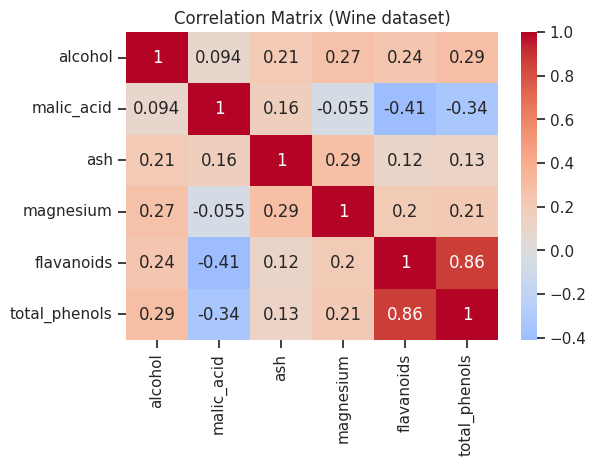

In [ ]:
plt.figure(figsize=(6, 4))       # Create a new figure with size 6×4 inches

# Create and display the correlation matrix as a heatmap:
# - df[cols].corr(): calculates the (Pearson) correlation between the selected columns
# - annot=True: writes the correlation values into the cells
# - cmap="coolwarm": color scale (negative ↔ positive correlation)
# - center=0: the center of the color scale is 0 (so negative/positive values are clearly separated)
sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix (Wine dataset)")  # Title of the figure
plt.show()                                     # Display the figure


**What do we see in the correlation matrix?**

- The diagonal contains only 1s, because a variable
perfectly correlates with itself.  
- The off-diagonal values show the **strength and direction of the linear relationship**
between variables, between −1 and 1.

- Among the examined variables, mostly **weak correlations** can be observed.
- There is a strong positive relationship between `flavanoids` and `total_phenols`, while a negative relationship can be seen between `malic_acid` and `flavanoids`.





## Visual verification (regplot)

The correlation matrix quickly shows whether two variables **move together**.

But it is important to remember that correlation is only a number.
Therefore, it is always useful to **check visually** whether the relationship really looks the way the number suggests.

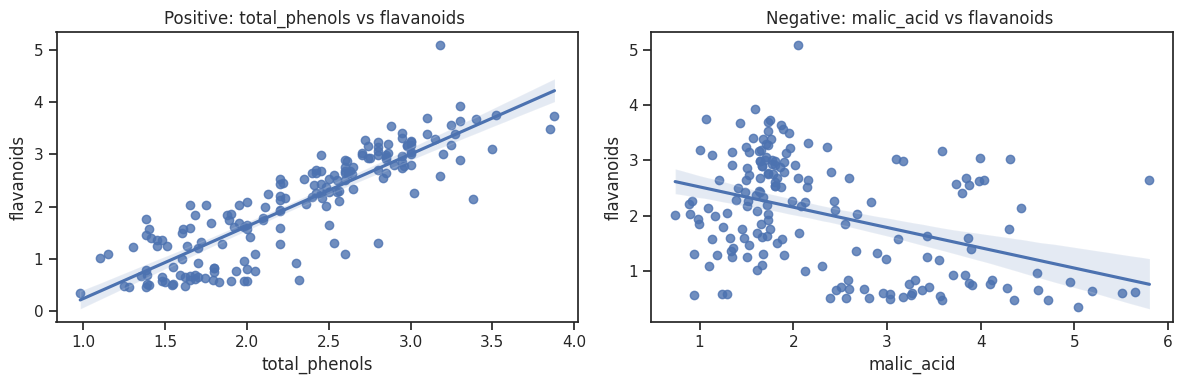

In [ ]:
# Visualization with regplot: scatter plot + linear fit (trend line)
# We create two subplots next to each other:
# - on the left a positively correlated pair
# - on the right a negatively correlated pair
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Positive relationship
# sns.regplot:
# - draws the data points (scatter)
# - and fits a simple linear regression line (trend line)
sns.regplot(
    data=df,
    x=df['total_phenols'],
    y=df['flavanoids'],
    ax=axes[0]           # draw on the first subplot
)
axes[0].set_title(f"Positive: total_phenols vs flavanoids ")

# Negative relationship
# Same idea, but for the negatively correlated variable pair.
sns.regplot(
    data=df,
    x=df["malic_acid"],
    y=df['flavanoids'],
    ax=axes[1]           # draw on the second subplot
)
axes[1].set_title(f"Negative: malic_acid vs flavanoids ")

plt.tight_layout()  # Adjust layout so the subplots do not overlap
plt.show()          # Display the figures

## Pearson and Spearman Correlation

Correlation measures the relationship between two variables.
However, it is important to distinguish **what type of relationship** we are looking for.

- **Pearson correlation** measures a linear relationship and is sensitive to
  outliers.
- **Spearman correlation** works based on ranks, so it also performs well
  when the relationship is not linear but monotonic.

Choosing the appropriate correlation always depends on the nature of the data.


Example – Salary, education, age (Spearman)

In [ ]:
np.random.seed(42)  # Reproducibility: we get the same random numbers each time we run the code

n = 100  # We generate this many “employees” (samples)

# Creating an artificial (simulated) dataset
# - age: random age between 22 and 65
# - education_level: random education category with given probabilities (p)
df_salary = pd.DataFrame({
    "age": np.random.randint(22, 65, n),
    "education_level": np.random.choice(
        ["high_school", "bachelor", "master", "phd"],
        size=n,
        p=[0.3, 0.4, 0.2, 0.1]
    )
})

# Ranking education levels (category → ordinal number)
# This is necessary because correlation is defined for numerical variables,
# and this way education is placed on an ordered (ordinal) scale.
education_rank = {
    "high_school": 1,
    "bachelor": 2,
    "master": 3,
    "phd": 4
}

# Convert the text category to a numeric rank using map()
df_salary["education_rank"] = df_salary["education_level"].map(education_rank)

# Simulating salary
# Salary:
# - increases monotonically with education level,
# - but NOT linearly: the step sizes between levels are defined manually,
#   so the relationship illustrates the monotonic but non-linear case,
# - age has only a smaller effect,
# - and noise is added to create more realistic data.
salary_steps = {
    1: 1000,    # high_school
    2: 3000,    # bachelor
    3: 6000,    # master
    4: 25000    # phd
}

df_salary["salary"] = (
    df_salary["education_rank"].map(salary_steps)
    + df_salary["age"] * 5
    + np.random.normal(0, 500, n)  # noise: std ~500
)

df_salary.head()  # Display the first few rows

,age,education_level,education_rank,salary
0,60,master,3,5908.373354
1,50,bachelor,2,3088.969242
2,36,bachelor,2,3586.758609
3,64,high_school,1,704.567842
4,29,bachelor,2,3258.729967


In [ ]:
df_salary[["salary", "age", "education_rank"]].corr(method="spearman")


,salary,age,education_rank
salary,1.000000,0.013893,0.943015
age,0.013893,1.000000,-0.009973
education_rank,0.943015,-0.009973,1.000000


In [ ]:
# Calculate Pearson and Spearman correlation
pearson_corr = df_salary["education_rank"].corr(df_salary["salary"], method="pearson")
spearman_corr = df_salary["education_rank"].corr(df_salary["salary"], method="spearman")

In [ ]:
# Calculate group means by education level
group_mean = (
    df_salary.groupby(["education_rank", "education_level"], as_index=False)["salary"]
    .mean()
    .sort_values("education_rank")
)

In [ ]:
group_mean

,education_rank,education_level,salary
0,1,high_school,1340.482069
1,2,bachelor,3297.088513
2,3,master,6084.367284
3,4,phd,25264.046567


In [ ]:
# IMPORTANT: This does not need to be learned, we only use it for visual comparison.

# Small horizontal jitter so that the points do not completely overlap
x_jitter = df_salary["education_rank"] + np.random.normal(0, 0.06, len(df_salary))

# Calculate linear fit to illustrate Pearson correlation
coef = np.polyfit(df_salary["education_rank"], df_salary["salary"], 1)
x_line = np.linspace(1, 4, 100)
y_line = np.polyval(coef, x_line)

In [ ]:
# Order of categories for a cleaner visualization
order = ["high_school", "bachelor", "master", "phd"]

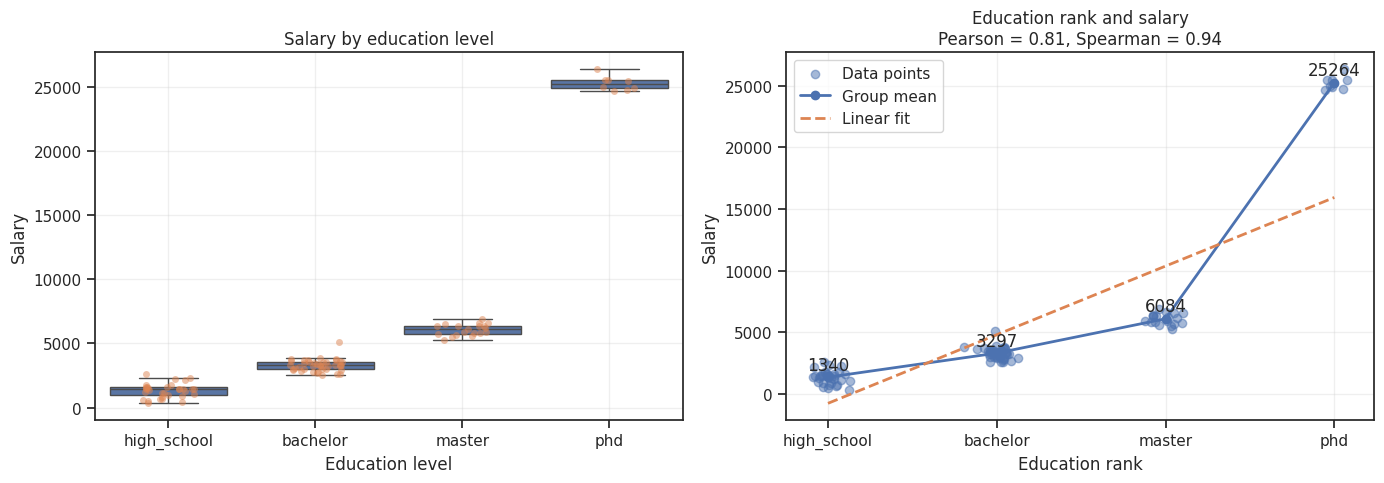

In [ ]:
# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: salary distribution by education category
sns.boxplot(
    data=df_salary,
    x="education_level",
    y="salary",
    order=order,
    showfliers=False,
    ax=axes[0]
)

sns.stripplot(
    data=df_salary,
    x="education_level",
    y="salary",
    order=order,
    jitter=0.18,
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Salary by education level")
axes[0].set_xlabel("Education level")
axes[0].set_ylabel("Salary")
axes[0].grid(True, alpha=0.3)

# Plot 2: relationship between numeric rank and salary
axes[1].scatter(x_jitter, df_salary["salary"], alpha=0.5, label="Data points")
axes[1].plot(
    group_mean["education_rank"],
    group_mean["salary"],
    marker="o",
    linewidth=2,
    label="Group mean"
)
axes[1].plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2,
    label="Linear fit"
)

# Display group mean values on the plot
for _, row in group_mean.iterrows():
    axes[1].text(
        row["education_rank"],
        row["salary"] + 600,
        f'{row["salary"]:.0f}',
        ha="center"
    )

axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(order)
axes[1].set_title(
    f"Education rank and salary\nPearson = {pearson_corr:.2f}, Spearman = {spearman_corr:.2f}"
)
axes[1].set_xlabel("Education rank")
axes[1].set_ylabel("Salary")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

What do we see in the figure?

Salary increases together with education level, therefore the relationship is monotonic. However, the increase is not linear, because the differences between education levels are not equal: especially at the PhD level a large jump can be observed. Because of this, Spearman correlation, which measures rank order and monotonic relationships, will typically be stronger than Pearson correlation, which measures the strength of a linear relationship.

## Global vs. Group-wise Correlation

- Correlation is often calculated for the entire dataset.
- However, this can be misleading if the data consists of **different groups** (subpopulations).
- In such cases, the global correlation may appear weak or strong, while within the individual groups a completely different relationship can be observed.
- We will illustrate this using the IRIS dataset.


In [ ]:
from sklearn.datasets import load_iris  # Load the built-in (offline) Iris dataset from scikit-learn
import pandas as pd                    # Pandas: DataFrame handling

# Load Iris data in DataFrame format
iris = load_iris(as_frame=True)

# Copy the complete DataFrame (features + target)
df_iris = iris.frame.copy()
df_iris["target"] = df_iris["target"].map(dict(enumerate(iris.target_names)))

df_iris.head()  # Quick check: display the first few rows

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Names of the numerical features in the Iris dataset
numeric_features = iris.feature_names

# Calculate the correlation matrix for the numerical columns
# By default, it computes Pearson correlation (linear association).
df_iris[numeric_features].corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


This table shows the Pearson correlation matrix of the numerical features in the Iris dataset (values between −1 and +1).

- The two petal features (petal length and petal width) move very strongly together (0.96).
- Sepal length is also strongly associated with petal length (0.87) and petal width (0.82).
- Sepal width tends to have a negative relationship with the petal features (e.g., −0.43 with petal length).

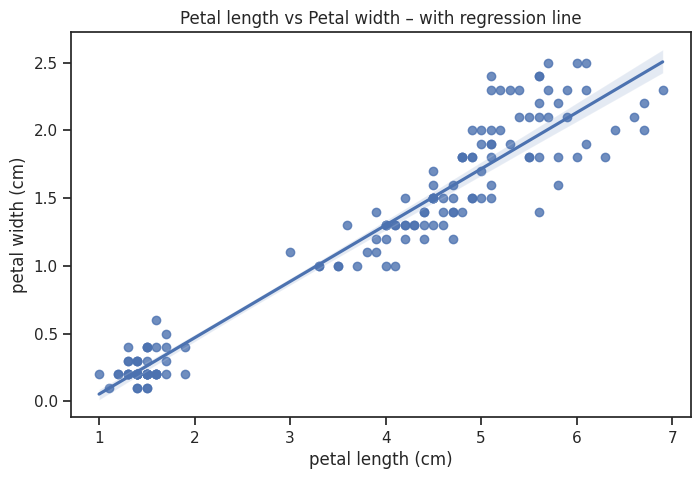

In [ ]:
plt.figure(figsize=(8, 5))       # Create a new figure with size 8×5 inches

sns.regplot(
        data=df_iris,
        x="petal length (cm)",     # X-axis: petal length
        y="petal width (cm)",      # Y-axis: petal width
        scatter=True               # also draw the data points

    )

plt.title("Petal length vs Petal width – with regression line")  # Title of the figure
plt.xlabel("petal length (cm)")                                  # X-axis label
plt.ylabel("petal width (cm)")                                   # Y-axis label
plt.show()

### What do we see in the figure?

- The plot shows the relationship between petal length and petal width (the points represent individual samples), and the fitted line indicates the linear trend.
- The trend line rises steeply → there is a positive relationship: the longer the petal, the wider it tends to be.
- The points lie relatively close to the line → the relationship is quite strong (there is little “scatter” around the trend).
- The scatter also indicates that the relationship is not perfect: petals with the same length can still have different widths.

Message: here the correlation is not just a number; the point cloud and the regression line also make the relationship visible.

In [ ]:
# Calculating correlation by groups:
# - groupby("target"): create separate groups for each iris species (setosa/versicolor/virginica)
# - [features]: work only with the selected numerical features
# - .corr(): compute the correlation matrix within each group
#
# The result will be a table with a multi-level index (MultiIndex):
# first level: target (species), followed by the row/column indices of the correlation matrix.
group_corr = (
    df_iris
    .groupby("target")[numeric_features]
    .corr()
)

group_corr  # Display the correlation matrices for each group

sepal length (cm)  sepal width (cm)  \
target                                                              
setosa     sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
versicolor sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
virginica  sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537728   

                              petal length (cm)  petal width (cm)  
target                                                             
setosa     sepal length (cm)           0.267176          0.278098  
           sepal width (cm)            0.177700          0.232752  
           petal length (cm)           1.000000          0.331630  
           petal width (cm)            0.331630          1.000000  
versicolor sepal length (cm)           0.754049          0.546461  
           sepal width (cm)            0.560522          0.663999  
           petal length (cm)           1.000000          0.786668  
           petal width (cm)            0.786668          1.000000  
virginica  sepal length (cm)           0.864225          0.281108  
           sepal width (cm)            0.401045          0.537728  
           petal length (cm)           1.000000          0.322108  
           petal width (cm)            0.322108          1.000000

**What do we see?**

- Based on the global correlation matrix, it may appear that certain variables (e.g., petal length and petal width) move very strongly together.
- However, if we examine the correlations by species, we can see that the strength and nature of the relationship differ significantly across the groups.
- For example, in the case of setosa, the relationship between petal measurements is much weaker than in the versicolor or virginica species.
- This shows that global correlation “averages” the behavior of different groups and can therefore hide important details.

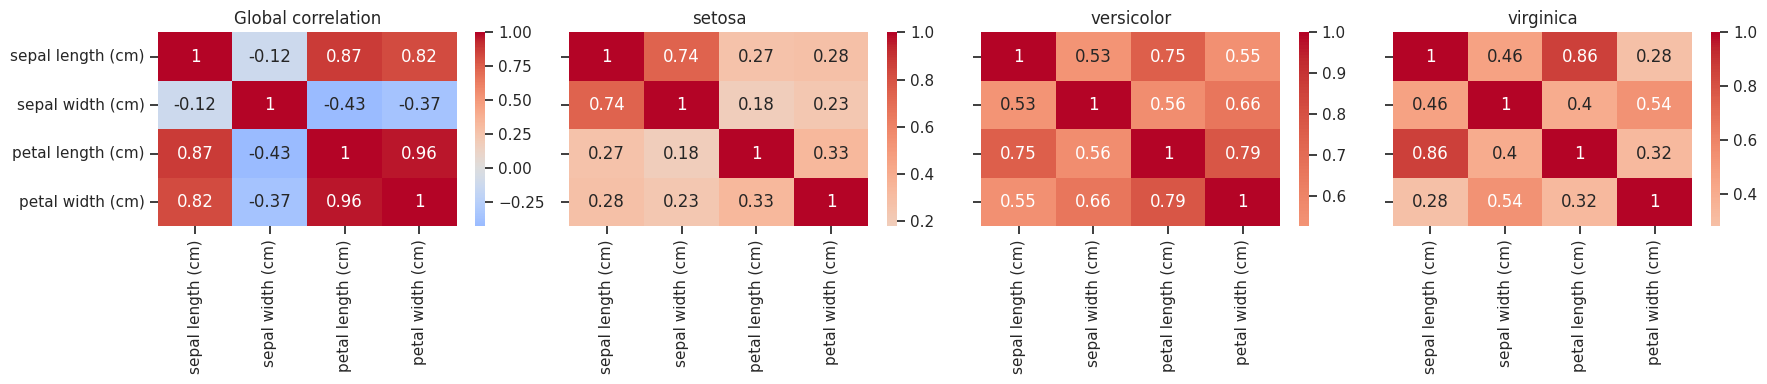

In [ ]:
features = iris.feature_names  # Names of the numerical features in the Iris dataset

# We create 4 plots (subplots) in one row
# sharey=True: shared Y-axis so the panels can be visually compared
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

# Global correlation matrix (Pearson)
sns.heatmap(
    df_iris[features].corr(),  # correlation on the full dataset
    annot=True,                # write the values into the cells
    cmap="coolwarm",           # color scale: negative ↔ positive
    center=0,                  # 0 is the center of the color scale
    ax=axes[0]                 # draw on the first subplot
)
axes[0].set_title("Global correlation")

# Correlation matrices by species
# df_iris.groupby("target") -> returns separate DataFrames for each species
# zip(axes[1:], ...) -> pair subplots 2–4 with the groups
for ax, (species, group) in zip(axes[1:], df_iris.groupby("target")):
    sns.heatmap(
        group[features].corr(),  # correlation only for samples of the given species
        annot=True,
        cmap="coolwarm",
        center=0,
        ax=ax
    )
    ax.set_title(species)        # subplot title: the species name

plt.tight_layout()  # Adjust layout so the titles do not overlap
plt.show()          # Display the plots

### Local Regression

Let us also examine the regression lines.

The expectation is that if the local correlation is weaker than the global one, then this will also become visible in the group-wise regression analysis.

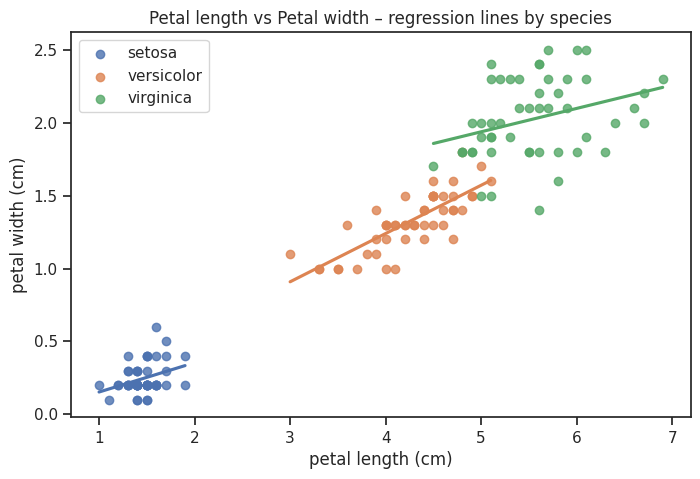

In [ ]:
plt.figure(figsize=(8, 5))       # Create a new figure with size 8×5 inches

# For each species (target category), we draw the points and the regression line separately.
for species in df_iris["target"].unique():
    # Select the rows belonging to the given species
    sub = df_iris[df_iris["target"] == species]

    # Scatter plot + linear regression fit for the samples of the given species
    sns.regplot(
        data=sub,
        x="petal length (cm)",     # X-axis: petal length
        y="petal width (cm)",      # Y-axis: petal width
        label=species,             # species name in the legend
        scatter=True,              # also draw the points
        ci=None                    # disable confidence interval (clearer and faster)
    )

plt.title("Petal length vs Petal width – regression lines by species")  # Title of the figure
plt.xlabel("petal length (cm)")                                         # X-axis label
plt.ylabel("petal width (cm)")                                          # Y-axis label
plt.legend()                                                            # Display legend
plt.show()

### What do we see in the figure?

- The lines show the linear trend for each species: for all three species the relationship is positive (longer petals usually correspond to wider petals), but the **strength/slope** of the relationship differs.
- The grouping is clearly visible: setosa is separated from the other two (shorter and narrower petals), while versicolor and virginica appear in a higher range with partial overlap.

Message: the same two variables may show correlation globally, but when examined by species the pattern can differ, therefore it is useful to analyze them by groups as well.

## Tasks – Titanic dataset

The purpose of the following tasks is to use the Titanic dataset
to practice the interpretation of distributions, missing values, and relationships
between variables.

Let us load the TITANIC dataset from the following link:

'https://www.inf.u-szeged.hu/~korosig/teach/datasets/dirty_titanic.csv'

### Task 1
Examine the missing values in the Titanic dataset.

- Which columns contain missing data?
- Calculate the proportion of missing values by column (%).
- Briefly describe which variable causes the biggest problem and why.


In [1]:
import pandas as pd

url = 'https://www.inf.u-szeged.hu/~korosig/teach/datasets/dirty_titanic.csv'
df = pd.read_csv(url)

missing = df.isna().sum()
missing_percent = df.isna().mean() * 100

print(missing)
print(missing_percent)

pclass          0
name            0
sex           137
age           381
sibsp           0
parch           0
ticket          0
fare          138
cabin        1066
embarked      137
boat          868
body         1245
home.dest     595
survived        0
dtype: int64
pclass        0.000000
name          0.000000
sex           9.970888
age          27.729258
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare         10.043668
cabin        77.583697
embarked      9.970888
boat         63.173217
body         90.611354
home.dest    43.304221
survived      0.000000
dtype: float64


### Task 2
Calculate the correlation between the following variables:
- `Age`
- `Fare`
- `Survived`

- Create a correlation matrix.
- Which relationships are strong and which are weak?
- Explain to what extent the obtained correlations are interpretable.

In [4]:
corr_matrix = df[['age','fare','survived']].corr()
print(corr_matrix)

               age      fare  survived
age       1.000000  0.148962 -0.079463
fare      0.148962  1.000000  0.238421
survived -0.079463  0.238421  1.000000


### Task 3
Examine the relationship between `Fare` and `Survived`:

- Calculate the correlation.
- Then calculate the correlation separately by gender (`Sex`).
- Compare the results, and describe
  what this tells us about the limitations of correlation.

In [5]:
overall_corr = df['fare'].corr(df['survived'])
male_corr = df[df['sex']=='male']['fare'].corr(df[df['sex']=='male']['survived'])
female_corr = df[df['sex']=='female']['fare'].corr(df[df['sex']=='female']['survived'])

print("Overall correlation:", overall_corr)
print("Male correlation:", male_corr)
print("Female correlation:", female_corr)

Overall correlation: 0.23842137787423587
Male correlation: 0.1334654941994981
Female correlation: 0.2229783444966025
